<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/06wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-wNdBL6UCsRKADoJyirz9ZD&si=8LVtt3vTeU2dLy-3>}}

# 2. Imports

In [10]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
plt.rcParams['figure.figsize'] = (4.5,3.0)

# 3. `matplotlib` 고마워

## A. 고마움1

In [5]:
Y = torch.tensor([[-1,2],[2,4],[4,2],[2,1]])
Y

tensor([[-1,  2],
        [ 2,  4],
        [ 4,  2],
        [ 2,  1]])

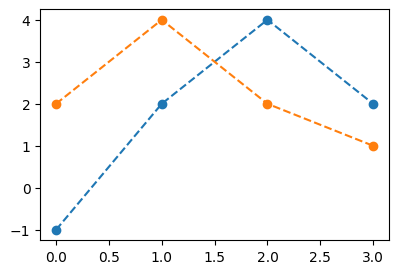

In [6]:
plt.plot(Y,'--o')

## B. 고마움2

`-` 이건 원래 되는 기능

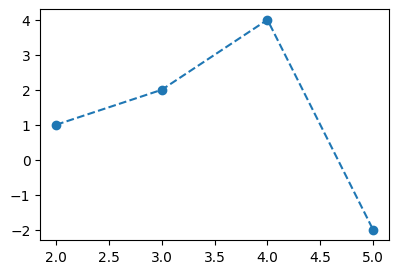

In [5]:
x = torch.tensor([2,3,4,5])
y = torch.tensor([1,2,4,-2])
plt.plot(x,y,'--o')

`-` 그런데 아래도 가능함

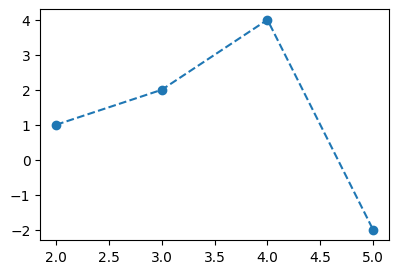

In [6]:
X = torch.tensor([2,3,4,5]).reshape(4,1) # shape=[4,1]
y = torch.tensor([1,2,4,-2]) # shape=[4]
plt.plot(X,y,'--o') # 사실 차원이 안맞았는데.. 잘 그려줌..

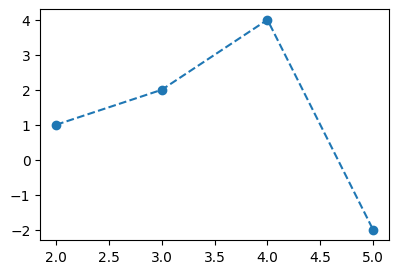

In [7]:
x = torch.tensor([2,3,4,5]) # shape=[4]
Y = torch.tensor([1,2,4,-2]).reshape(4,1) # shape=[4,1]
plt.plot(x,Y,'--o') # 사실 차원이 안맞았는데.. 잘 그려줌..

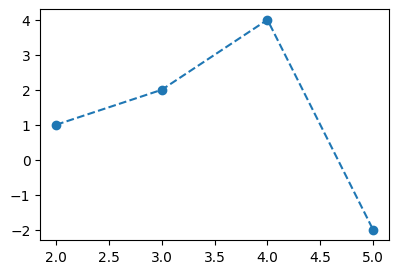

In [8]:
X = torch.tensor([2,3,4,5]).reshape(4,1) # shape=[4,1]
Y = torch.tensor([1,2,4,-2]).reshape(4,1) # shape=[4,1]
plt.plot(X,Y,'--o')

# 4. 로지스틱의 한계

## A. 스펙의 역설

`-` [스펙이 높아도 취업이 안된다고 합니다..](https://www.joongang.co.kr/article/23637092#home)

**중소·지방 기업 "뽑아봤자 그만두니까"**

중소기업 관계자들은 고스펙 지원자를 꺼리는 이유로 높은 퇴직률을 꼽는다. 여건이 좋은 대기업으로 이직하거나 회사를 관두는 경우가 많다는 하소연이다. 고용정보원이 지난 3일 공개한 자료에 따르면 중소기업 청년취업자 가운데 49.5%가 2년 내에 회사를 그만두는 것으로 나타났다.

중소 IT업체 관계자는 "기업 입장에서 가장 뼈아픈 게 신입사원이 그만둬서 새로 뽑는 일"이라며 "명문대 나온 스펙 좋은 지원자를 뽑아놔도 1년을 채우지 않고 그만두는 사원이 대부분이라 우리도 눈을 낮춰 사람을 뽑는다"고 말했다.

`-` 위의 기사를 모티브로 한 데이터

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/guebin/DL2026/refs/heads/master/posts/irony_of_spec.csv")
df

,x,prob,y
0,-1.000000,0.000045,0.0
1,-0.998999,0.000046,0.0
2,-0.997999,0.000047,0.0
3,-0.996998,0.000047,0.0
4,-0.995998,0.000048,0.0
...,...,...,...
1995,0.995998,0.505002,0.0
1996,0.996998,0.503752,0.0
1997,0.997999,0.502501,0.0
1998,0.998999,0.501251,1.0


In [10]:
x = torch.tensor(df.x).float()
y = torch.tensor(df.y).float()
prob = torch.tensor(df.prob).float()

## B. 박혜원씨의 관찰

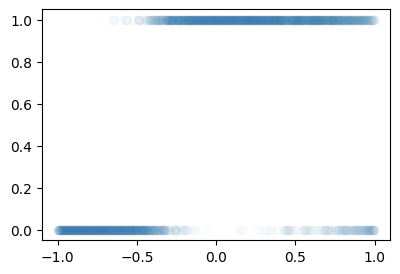

In [11]:
plt.plot(x,y,'o',alpha=0.02)

## C. True (박혜원씨는 이걸 모름)

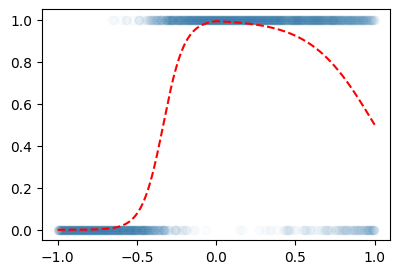

In [12]:
plt.plot(x,y,'o',alpha=0.02)
plt.plot(x,prob,'--r')

## D. 다시 박혜원씨의 세상으로

In [13]:
X = x.reshape(-1,1)
Y = y.reshape(-1,1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters()) # 국민옵티마이저 Adam사용
#---#
for epoch in range(5000):
    ## Step1. Yhat만들기
    Yhat = net(X)
    ## Step2. loss계산
    loss = loss_fn(Yhat,Y)
    ## Step3. 미분
    loss.backward()
    ## Step4. 업데이트
    optimizer.step()
    optimizer.zero_grad()

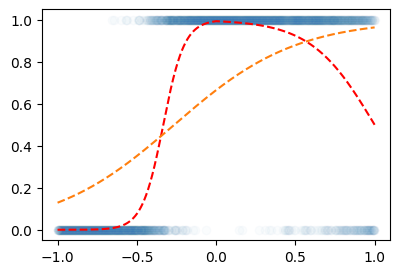

In [14]:
plt.plot(X,Y,'o',alpha=0.02)
plt.plot(X,prob,'--r')
plt.plot(X,net(X).data,'--')

`-` 망했음..

## E. 범인찾기


`-` 뭐가 문제인지 아래의 코드에서 살펴보자.


```Python
for epoch in range(5000):
    ## Step1. Yhat만들기
    Yhat = net(X)
    ## Step2. loss계산
    loss = loss_fn(Yhat,Y)
    ## Step3. 미분
    loss.backward()
    ## Step4. 업데이트
    optimizer.step()
    optimizer.zero_grad()
```    

`-` Step1에서 `Yhat`을 만드는 과정자체가 문제임

`-` 그럼 어쩌라고?? sigmoid에 넣기 전의 상태가 직선이 아니라 꺽이는 직선이어야 한다.

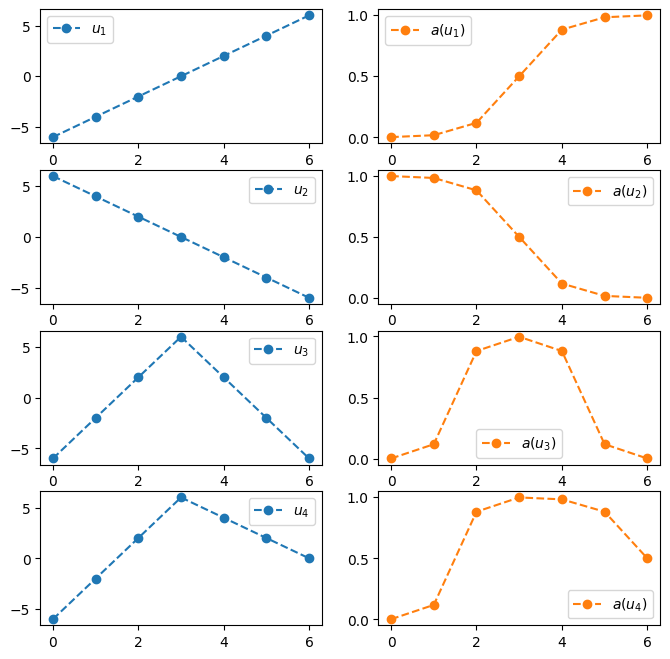

In [15]:
a = torch.nn.Sigmoid()
u1 = torch.tensor([-6,-4,-2,0,2,4,6])
u2 = torch.tensor([6,4,2,0,-2,-4,-6])
u3 = torch.tensor([-6,-2,2,6,2,-2,-6])
u4 = torch.tensor([-6,-2,2,6,4,2,0])
#---#
fig,ax = plt.subplots(4,2,figsize=(8,8))
ax[0,0].plot(u1,'--o',label=r"$u_1$"); ax[0,0].legend()
ax[0,1].plot(a(u1),'--o',color="C1",label=r"$a(u_1)$"); ax[0,1].legend()
ax[1,0].plot(u2,'--o',label=r"$u_2$"); ax[1,0].legend()
ax[1,1].plot(a(u2),'--o',color="C1",label=r"$a(u_2)$"); ax[1,1].legend()
ax[2,0].plot(u3,'--o',label=r"$u_3$"); ax[2,0].legend()
ax[2,1].plot(a(u3),'--o',color="C1",label=r"$a(u_3)$"); ax[2,1].legend()
ax[3,0].plot(u4,'--o',label=r"$u_4$"); ax[3,0].legend()
ax[3,1].plot(a(u4),'--o',color="C1",label=r"$a(u_4)$"); ax[3,1].legend()

`-` 결국 아래의 네트워크 설계는 틀렸다.

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(1,1),
    torch.nn.Sigmoid()
)
```

`-` 왜?? 위의 네트워크가 표현할 수 있는 형태는 결국

1. 증가하는 S모양의 곡선
2. 감소하는 S모양의 곡선

뿐인데 실제 데이터는 1,2에 해당하지 않고 증가하다가 감소하는 형태의 곡선이기 때문. 즉 `net`가 표현하는 표현력이 너무 약하다.

# 5. 꺽인직선을 만드는 방법

`-` 스펙의역설 데이터를 적합시키기 위해서는 시그모이드를 취하기 전의 직선이 꺽인직선이어야함.

`-` 이번절에서는 꺽인직선을 만드는 방법들을 생각해보자.

`-` 아래와 같은 벡터 ${\bf x}$를 고려하자.

In [16]:
x = torch.linspace(-1,1,1001)
x

tensor([-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000])

`-` 목표: 아래와 같은 벡터 ${\bf y}$를 만들어 보자.

$${\bf y} = [y_1,y_2,\dots,y_n], \quad y_i = \begin{cases} 9x_i +4.5 & x_i \leq 0 \\ -4.5x_i + 4.5 & x_i > 0 \end{cases}$$

`# 방법1` -- 그냥 수식 그대로 구현

In [17]:
y = x*0
for i in range(1001):
    if x[i] < 0:
        y[i] = 9*x[i] + 4.5
    else:
        y[i] = -4.5*x[i] + 4.5

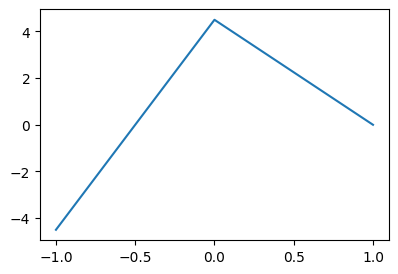

In [18]:
plt.plot(x,y)

`#`

`# 방법2` -- 렐루이용

In [19]:
relu = torch.nn.ReLU()

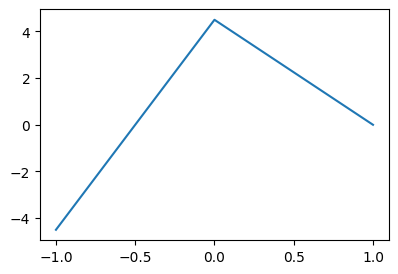

In [20]:
y = -9*relu(-x)-4.5*relu(x)+4.5
plt.plot(x,y)

`-` 좀 더 중간과정을 시각화해보자.

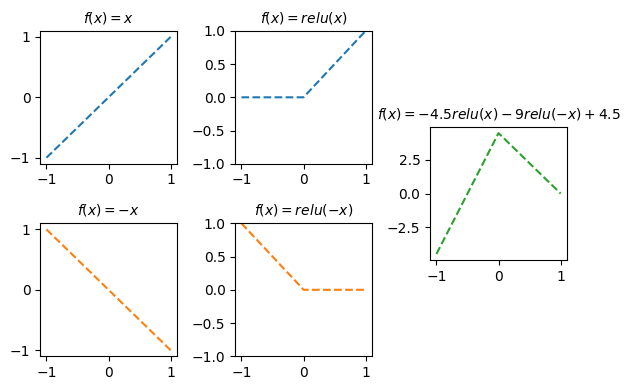

In [21]:
fig = plt.figure(figsize=(6,4))
spec = fig.add_gridspec(4,3)
ax1 = fig.add_subplot(spec[:2,0]); ax1.set_title(r"$f(x)=x$",fontsize=10)
ax2 = fig.add_subplot(spec[2:,0]); ax2.set_title(r"$f(x)=-x$",fontsize=10)
ax3 = fig.add_subplot(spec[:2,1]); ax3.set_title(r"$f(x)=relu(x)$",fontsize=10); ax3.set_ylim(-1,1)
ax4 = fig.add_subplot(spec[2:,1]); ax4.set_title(r"$f(x)=relu(-x)$",fontsize=10); ax4.set_ylim(-1,1)
ax5 = fig.add_subplot(spec[1:3,2]); ax5.set_title(r"$f(x)=-4.5relu(x)-9relu(-x)+4.5$",fontsize=10)
ax1.plot(x,x,'--',color="C0")
ax2.plot(x,-x,'--',color="C1")
ax3.plot(x,relu(x),'--',color="C0")
ax4.plot(x,relu(-x),'--',color="C1")
ax5.plot(x,-9*relu(-x)-4.5*relu(x)+4.5,'--',color="C2")
fig.tight_layout()

`# 방법3` -- relu + matrix 이용

`-` 위의 코드는 아래와 같이 쓸 수 있다.

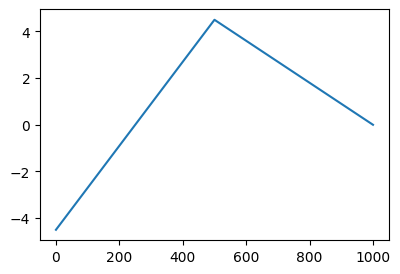

In [22]:
U = torch.stack([x,-x],axis=1)
V = relu(U)
Y = -4.5*V[:,[0]] -9.0*V[:,[1]] + 4.5
plt.plot(Y)

`-` 그런데.. 위의 코드는 다시 아래와 같이 쓸 수 있다.

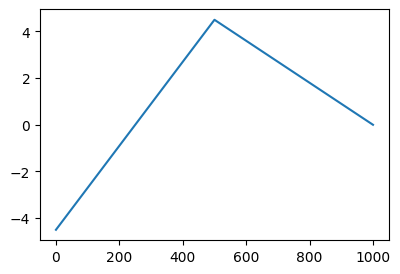

In [23]:
X = x.reshape(-1,1)
U = X @ torch.tensor([[1.0, -1.0]])
V = relu(U)
Y = V @ torch.tensor([[-4.5],[-9.0]]) + 4.5
plt.plot(Y)

`#`

`# 방법4` -- 파이토치문법이용

`-` 아래의 내용을 다시 잘 떠올려보자.

```Python
net = torch.nn.Linear(??,??,bias=False)
```

이렇게 선언하면 `net(X)` 는 `X @ net.weight.data.T` 와 같은 효과를 가진다.

```Python
net = torch.nn.Linear(??,??,bias=True)
```

이렇게 선언하면 `net(X)` 는 `X @ net.weight.data.T + net.bias.data` 와 같은 효과를 가진다.

`-` 방법3에서 썼던 코드는 아래와 같다.

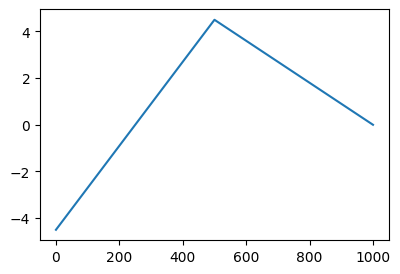

In [24]:
X = x.reshape(-1,1)
U = X @ torch.tensor([[1.0, -1.0]])
V = relu(U)
Y = V @ torch.tensor([[-4.5],[-9.0]]) + 4.5
plt.plot(Y)

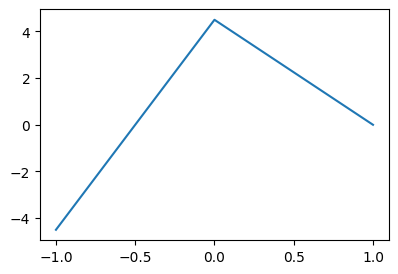

In [25]:
X = x.reshape(-1,1)
#---#
l1 = torch.nn.Linear(1,2,bias=False)
l1.weight.data = torch.tensor([[1.0,-1.0]]).T
U = l1(X)
#---#
relu = torch.nn.ReLU()
V = relu(U)
#---#
l2 = torch.nn.Linear(2,1,bias=True)
l2.weight.data = torch.tensor([[-4.5],[-9.0]]).T
l2.bias.data = torch.tensor([4.5])
Y = l2(V)
#---#
plt.plot(X,Y.data)

`-` 사실 더 깔끔하게는 아래와 같이 쓸 수 있다.

In [26]:
f = torch.nn.Sequential(
    torch.nn.Linear(1,2,bias=False),
    torch.nn.ReLU(),
    torch.nn.Linear(2,1,bias=True)
)
f[0].weight.data = torch.tensor([[1.0,-1.0]]).T
f[2].weight.data = torch.tensor([[-4.5],[-9.0]]).T
f[2].bias.data = torch.tensor([4.5])
f(X)

tensor([[-4.5000],
        [-4.4820],
        [-4.4640],
        ...,
        [ 0.0180],
        [ 0.0090],
        [ 0.0000]], grad_fn=<AddmmBackward0>)

`#`

# 6. 스펙의 역설 데이터 적합

`-` 스펙의역설을 다시 적합해보자.

In [27]:
df = pd.read_csv("https://raw.githubusercontent.com/guebin/DL2026/refs/heads/master/posts/irony_of_spec.csv")
x = torch.tensor(df.x).float()
y = torch.tensor(df.y).float()
prob = torch.tensor(df.prob).float()

`-` 실패했던풀이

In [28]:
X = x.reshape(-1,1)
Y = y.reshape(-1,1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters()) # 국민옵티마이저 Adam사용
#---#
for epoch in range(5000):
    ## Step1. Yhat만들기
    Yhat = net(X)
    ## Step2. loss계산
    loss = loss_fn(Yhat,Y)
    ## Step3. 미분
    loss.backward()
    ## Step4. 업데이트
    optimizer.step()
    optimizer.zero_grad()

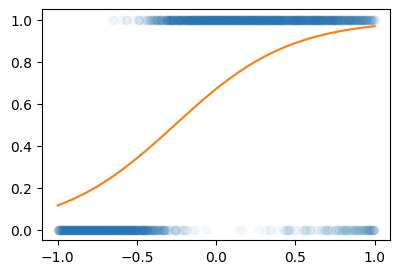

In [30]:
plt.plot(X,Y,'o',alpha=0.03)
plt.plot(X,net(X).data)

`-` 개선된 풀이: 시그모이드를 취하기 전의 형태가 그냥 직선이 아니라 꺽인 직선의 형태

In [54]:
X = x.reshape(-1,1)
Y = y.reshape(-1,1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,2,bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(2,1,bias=True),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters()) # 국민옵티마이저 Adam사용
#---#
for epoch in range(5000):
    ## Step1. Yhat만들기
    Yhat = net(X)
    ## Step2. loss계산
    loss = loss_fn(Yhat,Y)
    ## Step3. 미분
    loss.backward()
    ## Step4. 업데이트
    optimizer.step()
    optimizer.zero_grad()

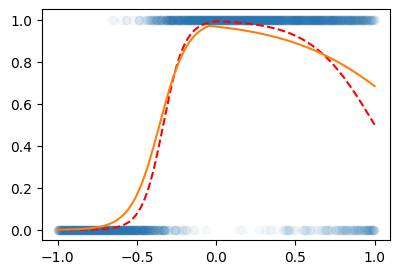

In [56]:
plt.plot(X,Y,'o',alpha=0.03)
plt.plot(X,prob,'--r')
plt.plot(X,net(X).data)

좀 아쉽네? 한번더!!

In [57]:
for epoch in range(5000):
    ## Step1. Yhat만들기
    Yhat = net(X)
    ## Step2. loss계산
    loss = loss_fn(Yhat,Y)
    ## Step3. 미분
    loss.backward()
    ## Step4. 업데이트
    optimizer.step()
    optimizer.zero_grad()

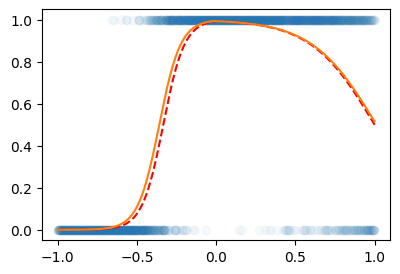

In [58]:
plt.plot(X,Y,'o',alpha=0.03)
plt.plot(X,prob,'--r')
plt.plot(X,net(X).data)

`-` 저번시간에 로직스틱에서 적합한 것도 위의 네트워크로 적합가능 (이 네트워크는 무조건 꺽이는 선만 표현하는건 아님)

In [59]:
!wget https://raw.githubusercontent.com/guebin/DL2026/master/posts/05wk-employed.pt
!wget https://raw.githubusercontent.com/guebin/DL2026/master/posts/05wk-spec.pt
spec = torch.load("05wk-spec.pt")
employed = torch.load("05wk-employed.pt")

--2026-04-12 15:21:47--  https://raw.githubusercontent.com/guebin/DL2026/master/posts/05wk-employed.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9619 (9.4K) [application/octet-stream]
Saving to: ‘05wk-employed.pt’

05wk-employed.pt    100%[===================>]   9.39K  --.-KB/s    in 0s      

2026-04-12 15:21:48 (71.9 MB/s) - ‘05wk-employed.pt’ saved [9619/9619]

--2026-04-12 15:21:48--  https://raw.githubusercontent.com/guebin/DL2026/master/posts/05wk-spec.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9591 (9.4K) [ap

In [62]:
X = spec.reshape(-1,1)
Y = employed.reshape(-1,1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,2,bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(2,1,bias=True),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters()) # 국민옵티마이저 Adam사용
#---#
for epoch in range(5000):
    ## Step1. Yhat만들기
    Yhat = net(X)
    ## Step2. loss계산
    loss = loss_fn(Yhat,Y)
    ## Step3. 미분
    loss.backward()
    ## Step4. 업데이트
    optimizer.step()
    optimizer.zero_grad()

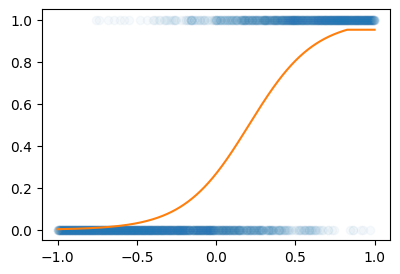

In [64]:
plt.plot(X,Y,'o',alpha=0.03)
plt.plot(X,net(X).data)

한번 더 돌려볼까?

In [80]:
for epoch in range(5000):
    ## Step1. Yhat만들기
    Yhat = net(X)
    ## Step2. loss계산
    loss = loss_fn(Yhat,Y)
    ## Step3. 미분
    loss.backward()
    ## Step4. 업데이트
    optimizer.step()
    optimizer.zero_grad()

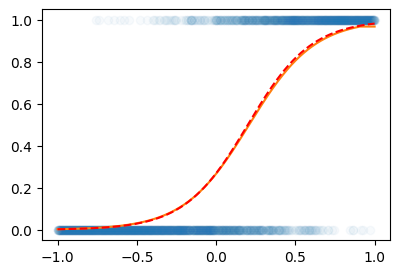

In [85]:
plt.plot(X,Y,'o',alpha=0.03)
plt.plot(X,net(X).data)
#---#
#궁금해서 true랑 비교
w0ast = -1
w1ast = 5
def sig(x):
    return torch.exp(x)/(torch.exp(x)+1)
piast = sig(w0ast+w1ast*x)
plt.plot(X,piast,'--r')

`-` 방금한 코드의 비판: 이 `net`

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(1,2,bias=True),
    torch.nn.ReLU(),
    torch.nn.Linear(2,1,bias=True),    
    torch.nn.Sigmoid()
)
```
은 저번시간에 배운 아래의 네트워크보다 학습할 파라메터가 3배 더 많음.

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(1,1),
    torch.nn.Sigmoid()
)
```

- 하지만 표현력은 더 좋죠? 꺽을수도있고, 안 꺽을수도 있고
- 실무적으로 적합하는게 걸리는 시간도 별로 차이안남

> 이때 강의영상에서 제가 설명을 잘못했어요. 첫번째 네트워크는 학습가능한 파라메터가 6개가 아니고 7개입니다. 그래서 "저번시간에 배운 아래의 네트워크보다 학습할 파라메터가 3배 더 많음." 이 표현도 "저번시간에 배운 아래의 네트워크보다 학습할 파라메터가 3.5배 더 많음." 으로 고쳐야합니다. 

# 7. 많이 꺽인그래프는 생각보다 좋음

`# 예제1` -- 일부러 이상하게 만든 취업합격률 곡선

In [89]:
torch.manual_seed(43052)
x = torch.linspace(-1,1,2000)
u = 0*x-3
u[x<-0.2] = (15*x+6)[x<-0.2]
u[(-0.2<x)&(x<0.4)] = (0*x-1)[(-0.2<x)&(x<0.4)]
sig = torch.nn.Sigmoid()
v = sig(u)
y = torch.bernoulli(v)

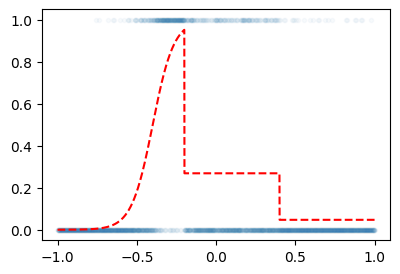

In [93]:
plt.plot(x,y,'.',alpha=0.03)
plt.plot(x,v,'--r')

In [151]:
X = x.reshape(-1,1)
Y = y.reshape(-1,1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters())
for epoch in range(3000):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

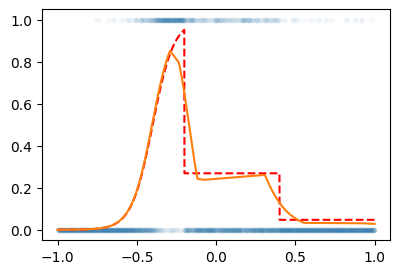

In [153]:
plt.plot(X,Y,'.',alpha=0.03)
plt.plot(X,v,'--r') # true: 박혜원씨는 모름
plt.plot(X,net(X).data)

- 딱 맞추진 못해서 상당히 그럴듯하게 맞춤..

더 적합시켜보면

In [154]:
for epoch in range(3000):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

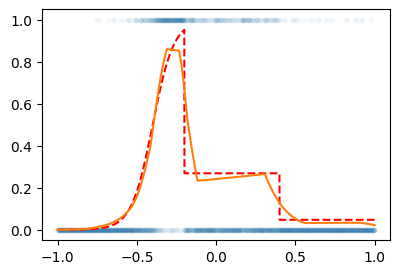

In [155]:
plt.plot(X,Y,'.',alpha=0.03)
plt.plot(X,v,'--r') # true: 박혜원씨는 모름
plt.plot(X,net(X).data)

`# 예제2` --  2024년 수능 미적30번 문제에 나온 곡선

$$y_i = e^{-x_i} \times  |\cos(5x_i)| \times \sin(5x) + \epsilon_i, \quad \epsilon_i \sim N(0,\sigma^2)$$

In [158]:
torch.manual_seed(43052)
x = torch.linspace(0,2,2000)
noise = torch.randn(2000)*0.05
structure = torch.exp(-1*x)* torch.abs(torch.cos(3*x))*(torch.sin(3*x))
y = structure + noise

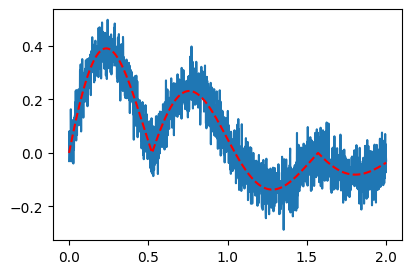

In [161]:
plt.plot(x,y)
plt.plot(x,structure,'--r') # 트루, 박혜원씨는 모름

In [177]:
X = x.reshape(-1,1)
Y = y.reshape(-1,1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1),
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
for epoch in range(3000):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

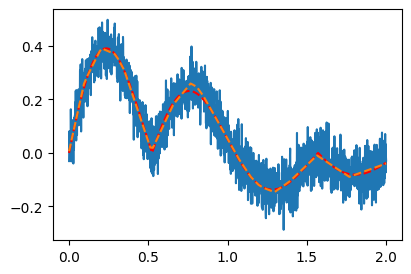

In [178]:
plt.plot(x,y)
plt.plot(x,structure,'--r') # 트루, 박혜원씨는 모름
plt.plot(X,net(X).data,'--') # 되게 그럴싸함.. 생각보다 잘맞춤